# LeNet-5 Architecture Implementation

This notebook implements the classic LeNet-5 convolutional neural network architecture, originally proposed by **Yann LeCun** et al. in the 1998 paper *"Gradient-Based Learning Applied to Document Recognition"*.

### Dependencies

To run this notebook, you will need `torch`, `torchvision`, and `matplotlib`. You can install them using:

```bash
pip install torch torchvision matplotlib
```

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## Model Implementation

LeNet-5 with ReLU activations and Max Pooling.

In [33]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        
        # Layer 1: Convolutional. Input: 1 channel, Output: 6 filters (5x5). Padding=2 for 28x28 input.
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        # Layer 2: Max Pooling (2x2), Stride 2.
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Layer 3: Convolutional. Input: 6 channels, Output: 16 filters (5x5).
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        # Layer 4: Max Pooling (2x2), Stride 2.
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Layer 5: Convolutional. Input: 16 channels, Output: 120 filters (5x5).
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)
        
        # Layer 6: Fully Connected.
        self.fc1 = nn.Linear(120, 84)
        
        # Layer 7: Output Layer.
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        # Convolution (C1) followed by ReLU activation and Max Pooling (S2)
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        
        # Convolution (C3) followed by ReLU activation and Max Pooling (S4)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        # Convolution (C5) followed by ReLU activation
        x = F.relu(self.conv3(x))
        
        # Flatten the output for the fully connected layers
        x = torch.flatten(x, 1)
        
        # Fully Connected (F6) with ReLU activation
        x = F.relu(self.fc1(x))
        
        # Output layer
        x = self.fc2(x)
        
        return x

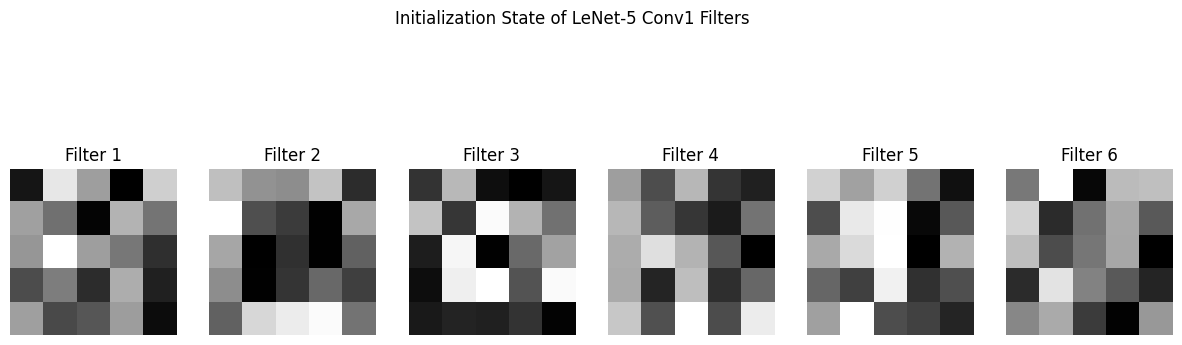

In [34]:
# Instantiate the model
model = LeNet5(num_classes=10)

# Extract filters from the first convolutional layer
filters = model.conv1.weight.detach()

# Plotting the filters
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    # Standard convolution filters have depth (channels); we take the first slice
    # Since MNIST is grayscale, input_channels = 1
    ax.imshow(filters[i, 0], cmap='gray')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')

plt.suptitle('Initialization State of LeNet-5 Conv1 Filters')
plt.show()

## Dataset Preparation

Loading the MNIST dataset of handwritten digits.

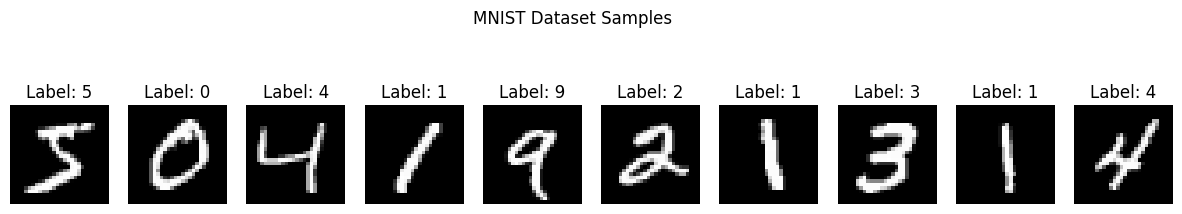

In [35]:
# Define transforms for the dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download the training data
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Display some samples from the dataset
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    image, label = train_dataset[i]
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f'Label: {label}')
    axes[i].axis('off')

plt.suptitle('MNIST Dataset Samples')
plt.show()

## Training the Model

Setting up the training loop with CrossEntropyLoss and Adam optimizer.

In [36]:
# Hyperparameters
batch_size = 64
learning_rate = 0.001
epochs = 5

# Create DataLoader
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# Device configuration (GPU usage if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        # Clear gradients
        optimizer.zero_grad()
        
        # Forward pass
        output = model(data)
        loss = criterion(output, target)
        
        # Backward pass and update weights
        loss.backward()
        optimizer.step()
        
        if (batch_idx + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

print("Training Complete!")

Epoch [1/5], Step [100/938], Loss: 0.2191
Epoch [1/5], Step [200/938], Loss: 0.1951
Epoch [1/5], Step [300/938], Loss: 0.1617
Epoch [1/5], Step [400/938], Loss: 0.1469
Epoch [1/5], Step [500/938], Loss: 0.0959
Epoch [1/5], Step [600/938], Loss: 0.1289
Epoch [1/5], Step [700/938], Loss: 0.0658
Epoch [1/5], Step [800/938], Loss: 0.1115
Epoch [1/5], Step [900/938], Loss: 0.0772
Epoch [2/5], Step [100/938], Loss: 0.0801
Epoch [2/5], Step [200/938], Loss: 0.0510
Epoch [2/5], Step [300/938], Loss: 0.0137
Epoch [2/5], Step [400/938], Loss: 0.0727
Epoch [2/5], Step [500/938], Loss: 0.0336
Epoch [2/5], Step [600/938], Loss: 0.0825
Epoch [2/5], Step [700/938], Loss: 0.1062
Epoch [2/5], Step [800/938], Loss: 0.0657
Epoch [2/5], Step [900/938], Loss: 0.0198
Epoch [3/5], Step [100/938], Loss: 0.0246
Epoch [3/5], Step [200/938], Loss: 0.0551
Epoch [3/5], Step [300/938], Loss: 0.0294
Epoch [3/5], Step [400/938], Loss: 0.0050
Epoch [3/5], Step [500/938], Loss: 0.0475
Epoch [3/5], Step [600/938], Loss: